# Clean & Professional Python Project Practices
A practical checklist for producing readable, reproducible engineering code.


## Professional Project Architecture

Avoid dumping everything into one folder. A structured directory makes your logic easy to follow and prevents your workspace from becoming a digital junk drawer.

```text
project_root/
│
├── src/                # All core logic
├── data/               # Raw data (never modify directly)
├── output/ or results/ # Plots, CSVs, logs
├── tests/              # Validation scripts
└── README.md           # Project overview & instructions
```

- **src/**: All your implementation logic goes here.  
- **data/**: Keep raw data separate. Never modify raw files via code; always save processed versions elsewhere.  
- **output/** or **results/**: Where plots, CSVs, and logs land.  
- **tests/**: Even simple scripts benefit from validation checks.  
- **README.md**: A quick "How-to" guide for anyone opening the project later.


## Eliminate "Magic Numbers"

A *magic number* is a hard-coded value with no explanation.

Bad:
```python
force = mass * 9.81
```

Better: define constants at the top of your script or in a `config.py` using **SCREAMING_SNAKE_CASE**.


In [31]:
# Example: replace magic numbers with named constants
GRAVITY = 9.81  # m/s^2

mass = 72.0  # kg
force = mass * GRAVITY
force

706.32

## Modularize: From Scripts to Modules

If your script exceeds ~200 lines, break it up (modular programming). A common layout:

| Component | Responsibility |
|---|---|
| `main.py` | Orchestrator: imports modules and runs high-level logic |
| `utils.py` | Small reusable helper functions |
| `processing.py` | Core math and data manipulation |
| `plotting.py` | Visualization functions |


## Readable Naming Conventions (PEP 8)

Python’s style guide is **PEP 8**:

- **Variables/Functions** → `snake_case`
- **Constants** → `ALL_CAPS`
- **Classes** → `PascalCase`


In [32]:
# Naming examples (PEP 8)
def calculate_stress(force, area):
    return force / area

MAX_PRESSURE = 300

class BridgeSimulation:
    def __init__(self, name: str):
        self.name = name

## Documentation & The Main Guard

Every script should begin with a docstring explaining purpose, inputs, and outputs.  
Use a *main guard* to avoid executing code on import.


In [33]:
# Example: "main guard" pattern (for scripts, not required in notebooks)
def main():
    # Your execution logic here
    pass

if __name__ == "__main__":
    main()

## Functional vs. Object-Oriented Programming (OOP)

**Use Functions** for linear data pipelines:

`Load → Filter → Analyze → Plot`

**Use Classes (OOP)** when modeling a physical “thing” with properties/behaviors (e.g., `Sensor`).


In [34]:
# OOP example: a simple Sensor abstraction
class Sensor:
    def __init__(self, port: str):
        self.port = port

    def read_data(self):
        # Placeholder for actual IO
        return {"port": self.port, "value": 1.234}

s = Sensor("COM3")
s.read_data()


{'port': 'COM3', 'value': 1.234}

LinearModel with coefficients: 2.20 and intercept: -1.00


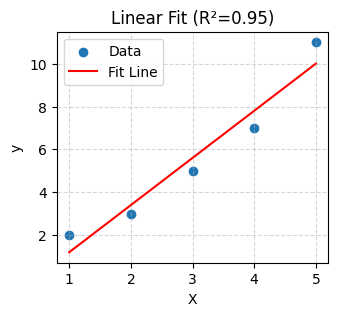

In [35]:
# OOP example for linear regression model
import numpy as np
from sklearn.linear_model import LinearRegression
class LinearRegressionModel:
    def __init__(self):
        self.model = LinearRegression()

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.model.fit(X, y)
        self.print_model()

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.model.predict(X)
    
    def print_model(self):
        # keep 2 decimal places for readability
        coef_str = ", ".join([f"{coef:.2f}" for coef in self.model.coef_])
        print(f"LinearModel with coefficients: {coef_str} and intercept: {self.model.intercept_:.2f}")
    
    def compute_r_squared(self, X, y):
        r_squared = self.model.score(X, y)
        return r_squared
    
    def plot_data_and_fit(self, X, y):
        import matplotlib.pyplot as plt
        plt.figure(figsize=(3.5, 3))
        plt.scatter(X, y, color='tab:blue', label='Data')
        plt.plot(X, self.predict(X), color='red', label='Fit Line')
        plt.xlabel('X')
        plt.ylabel('y')
        # add r2 value to the title
        r2 = self.compute_r_squared(X, y)
        plt.title(f'Linear Fit (R²={r2:.2f})')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.show()
# Example usage
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 3, 5, 7, 11])
model = LinearRegressionModel()
model.fit(X, y)
predictions = model.predict(X)
r_squared = model.compute_r_squared(X, y)
model.plot_data_and_fit(X, y)

RidgeModel with coefficients: 1.10 and intercept: 2.30
Alpha: 10.00


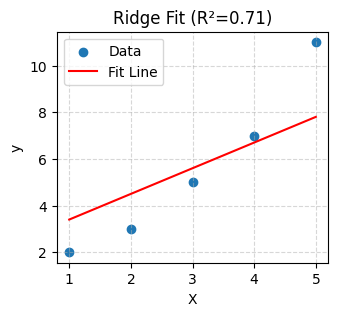

In [36]:
# now add ridge to the linear regression model
from sklearn.linear_model import Ridge
class RidgeRegressionModel(LinearRegressionModel):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.model = Ridge(alpha=alpha)
    
    def print_model(self):
        coef_str = ", ".join([f"{coef:.2f}" for coef in self.model.coef_])
        print(f"RidgeModel with coefficients: {coef_str} and intercept: {self.model.intercept_:.2f}\nAlpha: {self.model.alpha:.2f}")
    
    # update the plot method in the linear regression class
    def plot_data_and_fit(self, X: np.ndarray, y: np.ndarray):
        import matplotlib.pyplot as plt
        plt.figure(figsize=(3.5, 3))
        plt.scatter(X, y, color='tab:blue', label='Data')
        plt.plot(X, self.predict(X), color='red', label='Fit Line')
        plt.xlabel('X')
        plt.ylabel('y')
        
        # add r2 value to the title
        r2 = self.compute_r_squared(X, y)
        plt.title(f'Ridge Fit (R²={r2:.2f})')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.show()

# Example usage
ridge_model = RidgeRegressionModel(alpha=10)
ridge_model.fit(X, y)
ridge_model.plot_data_and_fit(X, y)

## Version Control (Git)

Use Git even for solo projects.

- Commits = save points  
- Easy rollback when experiments break  
- Enables collaboration and reproducibility


## Use Virtual Environments (venv)

Never install libraries globally. Create an isolated environment:

```bash
python -m venv .venv
```

Activate it and install dependencies per-project.


## Vectorization over Loops (The NumPy Rule)

Loops over large arrays are slow in pure Python. Prefer NumPy vectorization.


In [37]:
import numpy as np

arr = np.random.rand(1_000_000)

# Vectorized: fast
out = arr * 2.0
out[:5]

array([0.18268838, 0.11686867, 0.97097666, 1.2915487 , 1.80550085])

## Implement Logging instead of print()

Use `logging` so you can control verbosity (DEBUG/INFO/WARNING/ERROR) without editing dozens of `print()` calls.


In [38]:
import logging

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logging.info("Processing started")
logging.debug("This won't show unless level=DEBUG")

INFO: Processing started


## The DRY Principle (Don't Repeat Yourself)

If you copy-paste the same math formula or plotting code three times, wrap it in a function instead.

Benefits:
- Single source of truth
- Easier debugging
- Cleaner structure


## Defensive Programming (Error Handling)

Engineering data can be messy. Catch common issues (missing files, divide-by-zero, invalid units) so your run doesn’t crash mid-way.


In [39]:
def safe_divide(a, b):
    try:
        return a / b
    except ZeroDivisionError:
        return None

safe_divide(10, 0)

## Requirements and README.md Files

Include a `requirements.txt` (e.g., `pip install -r requirements.txt`) so others can recreate your environment exactly.

```
numpy==1.26.4
pandas==2.2.1
networkx==3.2.1
PyYAML==6.0.1
matplotlib==3.8.2
```


in README include:

```

This repository contains code for benchmarking xxx. 

## Setup

python -m venv bench_ml
source bench_ml/bin/activate
pip install -r requirements.txt
```

## Minimum Project Requirements

Your project must include:

- A clear entry script (e.g., `run_pipeline.py`)
- Modular code (no monolithic scripts > ~200 lines)
- At least one data processing module
- A model or algorithm module
- A README with:
  - project description
  - setup instructions
  - how to run the code
- A `requirements.txt` file

---

## Summary

Professional Python engineering projects prioritize:

- Structure
- Modularity
- Readability
- Reproducibility

Treat your codebase like an engineered system — not a scratch notebook.
